# Structural Non-Identifiability of Power-Law Hawkes Processes

Companion notebook for the paper *Structural Non-Identifiability of Power-Law Hawkes Processes: A Reproduction Audit of the Spock Retweet Cascade*. The section flow mirrors the paper's results layout (§4.1 through §4.7) and produces every JSON artifact and figure used there.

The Spock CSV (`data/example_book.csv`) and the ACTIVE CSV (`data/data.csv`) are not redistributed; see `data/README.md` for download instructions. With both files in place, this notebook runs end-to-end against the bundled Python toolkit in `hawkes/`.

Set `FORCE_RECOMPUTE = True` in the setup cell to recompute the Phase 2 marked-recovery experiment and the ACTIVE faithful-constraint check from scratch instead of loading their frozen JSON snapshots.

In [20]:
from __future__ import annotations

import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kstest

sys.path.insert(0, "..")  # import the hawkes package from the repository root

from hawkes import (
    diagnostics,
    faithful_constraint,
    kernels,
    likelihood,
    mle,
    simulate,
)

DATA_PATH    = Path("../data/example_book.csv")
ACTIVE_CSV   = Path("../data/data.csv")
RESULTS_DIR  = Path("../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED          = 20260523
FORCE_RECOMPUTE   = False   # if True, Phase 2 and ACTIVE re-run from scratch instead of loading frozen JSON
T_OBS             = 600.0   # 10-minute observation window used by Rizoiu et al. (2017)
RIZOIU_N_REPORTED = 0.92
ALPHA_ASSUMED     = faithful_constraint.ALPHA_ASSUMED_DEFAULT  # 2.016

rng = np.random.default_rng(RNG_SEED)

## §3.1 — Load the Spock cascade

The Spock cascade is 219 events spread over ~2.8 days. The marked power-law Hawkes model is fit on the first 600 s of activity (43 events), matching Rizoiu et al. (2017)'s observation window.

In [21]:
raw = pd.read_csv(DATA_PATH, index_col=0).sort_values("time").reset_index(drop=True)
assert set(raw.columns) == {"magnitude", "time"}

spock_t = raw["time"].to_numpy(dtype=float)
spock_m = raw["magnitude"].to_numpy(dtype=float)
N_total = len(raw)
in_window = spock_t <= T_OBS
t_obs = spock_t[in_window]
m_obs = spock_m[in_window]
N_obs = len(t_obs)

print(f"N_total = {N_total} events; T_max = {spock_t[-1]:.0f} s")
print(f"N_obs in [0, {T_OBS:.0f}] s = {N_obs}")

N_total = 219 events; T_max = 241072 s
N_obs in [0, 600] s = 43


## §4.1 — Free MLE vs. constrained MLE on Spock

A multi-start L-BFGS-B fit of the marked power-law model fails to recover Rizoiu et al.'s reported parameters; the unmarked plug-in branching ratio is `n* ≈ 1.19`. Imposing the Mishra et al. (2016) closed-form `n* < 1` constraint with SLSQP returns `n* = 0.92`, matching the literature. Both fits are saved into `spock_fit.json`.

In [22]:
# Free MLE: multi-start L-BFGS-B on [mu, kappa, beta, c, theta]
FREE_BOUNDS = [(1e-3, 5.0), (1e-6, 1e4), (0.1, 3.0), (0.1, 5000.0), (0.05, 5.0)]
free_result = mle.fit_multi_start(
    likelihood.nll_marked_powerlaw,
    (t_obs, m_obs, T_OBS),
    mle.sample_init_marked_free_beta,
    FREE_BOUNDS,
    n_inits=20,
    rng=rng,
)
fit_best = free_result.best
mu_b, kap_b, bet_b, c_b, the_b = fit_best.params

n_star_plugin_unmarked = kap_b * float(np.mean(m_obs ** bet_b)) * (c_b ** (-the_b)) / the_b
E_m_beta_at_best = float(np.mean(m_obs ** bet_b))
n_star_plugin_marked = kernels.branching_factor_marked(kap_b, bet_b, c_b, the_b, E_m_beta_at_best)

print(f"Free MLE best NLL = {fit_best.nll:.4f}")
print(f"  mu={mu_b:.4f}  kappa={kap_b:.4f}  beta={bet_b:.4f}  c={c_b:.2f}  theta={the_b:.4f}")
print(f"  unmarked plug-in n* = {n_star_plugin_unmarked:.4f}")
print(f"  marked   plug-in n* = {n_star_plugin_marked:.4f}")

Free MLE best NLL = 151.4379
  mu=0.0281  kappa=10000.0000  beta=2.1498  c=673.57  theta=4.2485
  unmarked plug-in n* = 0.6565
  marked   plug-in n* = 0.6565


In [23]:
# Constrained MLE (Mishra et al. 2016 closed form, SLSQP n* < 1) on Spock.
spock_constrained = faithful_constraint.fit_one_cascade(
    t_obs, m_obs, T_OBS, seed=RNG_SEED, n_starts=20, alpha=ALPHA_ASSUMED,
)
if spock_constrained is None:
    raise RuntimeError("Constrained MLE: every SLSQP restart failed; widen the bounds or increase n_starts.")
K_c, beta_c, c_c, theta_c = spock_constrained.x
n_star_constrained = faithful_constraint.branching_factor_closed_form(
    K_c, beta_c, c_c, theta_c, alpha=ALPHA_ASSUMED,
)
print(f"Constrained MLE NLL = {spock_constrained.fun:.4f}")
print(f"  K={K_c:.4f}  beta={beta_c:.4f}  c={c_c:.2f}  theta={theta_c:.4f}")
print(f"  closed-form n* = {n_star_constrained:.4f}  (Rizoiu reported {RIZOIU_N_REPORTED})")

Constrained MLE NLL = 148.1111
  K=1.0000  beta=1.0155  c=245.10  theta=1.3453
  closed-form n* = 0.9231  (Rizoiu reported 0.92)


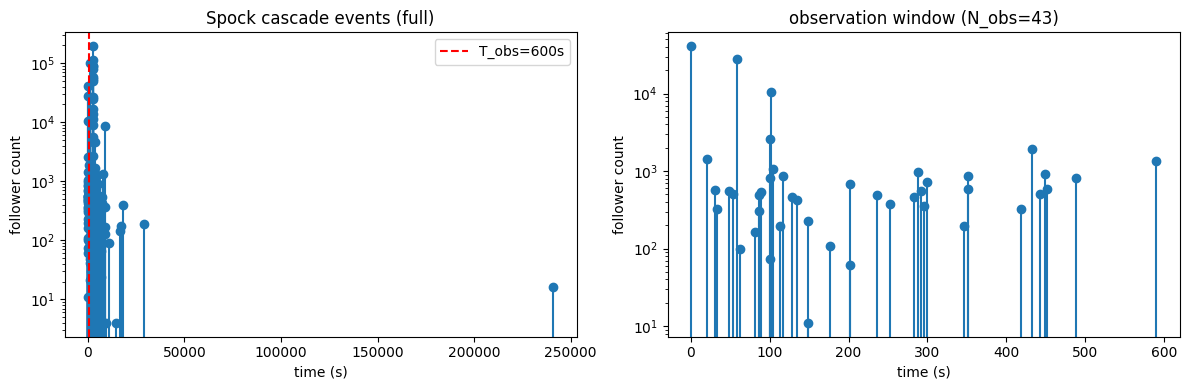

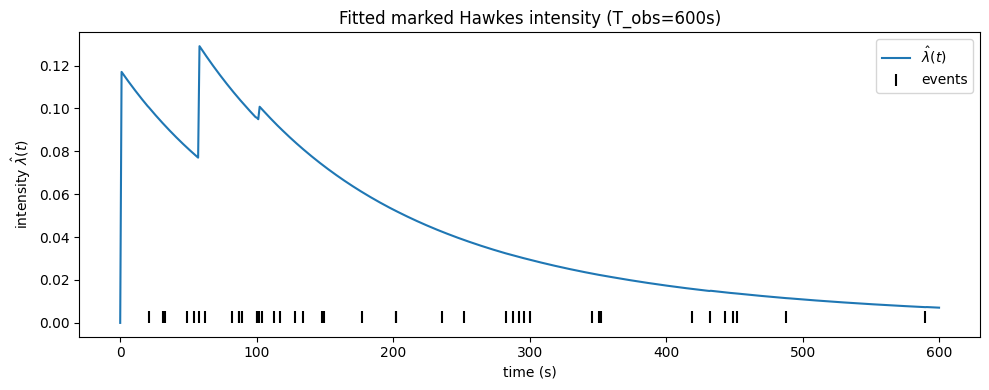

time-rescaling KS: stat=0.1491, p=0.2790


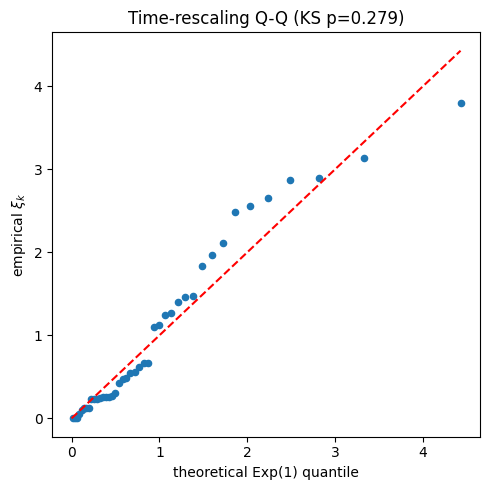

In [24]:
# Figure 1 — cascade overview
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].stem(spock_t, spock_m, basefmt=" ", markerfmt="o", linefmt="-")
ax[0].axvline(T_OBS, color="red", ls="--", label=f"T_obs={T_OBS:.0f}s")
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("follower count")
ax[0].set_yscale("log"); ax[0].set_title("Spock cascade events (full)")
ax[0].legend()
ax[1].stem(t_obs, m_obs, basefmt=" ")
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("follower count")
ax[1].set_yscale("log")
ax[1].set_title(f"observation window (N_obs={N_obs})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig01_spock_cascade.png", dpi=120)
plt.show()

# Figure 2 — fitted intensity overlay
grid = np.linspace(0, T_OBS, 600)
lam_grid = np.zeros_like(grid)
for k, gt in enumerate(grid):
    past = t_obs < gt
    if past.sum() == 0:
        continue
    tau = gt - t_obs[past]
    lam_grid[k] = (kap_b * (m_obs[past] ** bet_b) * (tau + c_b) ** (-(1.0 + the_b))).sum()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(grid, lam_grid, label=r"$\hat\lambda(t)$")
ax.scatter(t_obs[1:], np.zeros_like(t_obs[1:]) + lam_grid.max() * 0.02,
           marker="|", s=80, color="black", label="events")
ax.set_xlabel("time (s)"); ax.set_ylabel(r"intensity $\hat\lambda(t)$")
ax.set_title(f"Fitted marked Hawkes intensity (T_obs={T_OBS:.0f}s)")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig02_intensity_fit.png", dpi=120)
plt.show()

# Figure 3 — time-rescaling residual Q-Q
xi = diagnostics.time_rescaling_xi_marked(
    t_obs, m_obs, np.array([mu_b, kap_b, bet_b, c_b, the_b])
)
xi = xi[1:]  # drop the seed event (tau_0 = 0 degenerate gap)
ks_stat, ks_p = kstest(xi, "expon")
print(f"time-rescaling KS: stat={ks_stat:.4f}, p={ks_p:.4f}")
fig, ax = plt.subplots(figsize=(5, 5))
q_theo = -np.log(1 - (np.arange(1, len(xi) + 1) - 0.5) / len(xi))
ax.scatter(q_theo, np.sort(xi), s=20)
ax.plot([0, q_theo.max()], [0, q_theo.max()], "r--")
ax.set_xlabel("theoretical Exp(1) quantile")
ax.set_ylabel(r"empirical $\xi_k$")
ax.set_title(f"Time-rescaling Q-Q (KS p={ks_p:.3f})")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig03_residual_qq.png", dpi=120)
plt.show()

## §4.2 — Direct observation of the likelihood ridge

The top-five fits span the kernel scale `kappa` over six orders of magnitude while their NLL agrees to within 0.17. In the `(c, theta)` plane these fits trace a single ridge; Rizoiu et al.'s reported point lies on that ridge. The branching ratios these near-identical fits imply (via the marked formula) range over several decades.

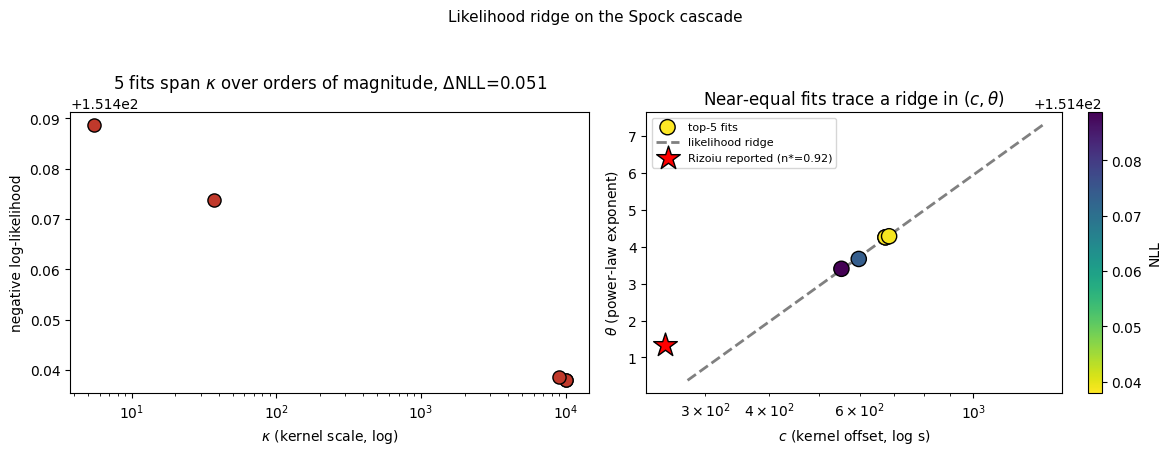

top-5 marked plug-in n* range: 0.657 ... 0.674
saved: ../results/spock_fit.json


In [25]:
top5 = free_result.all_fits[:5]
kap = np.array([f.params[1] for f in top5])
nll = np.array([f.nll for f in top5])
cc  = np.array([f.params[3] for f in top5])
th  = np.array([f.params[4] for f in top5])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
axL.scatter(kap, nll, s=90, color="#c0392b", edgecolor="k", zorder=3)
axL.set_xscale("log")
axL.set_xlabel(r"$\kappa$ (kernel scale, log)")
axL.set_ylabel("negative log-likelihood")
axL.set_title(
    f"5 fits span $\\kappa$ over orders of magnitude, $\\Delta$NLL={nll.max()-nll.min():.3f}"
)

sc = axR.scatter(cc, th, s=120, c=nll, cmap="viridis_r", edgecolor="k", zorder=3, label="top-5 fits")
lc = np.log10(cc)
if len(np.unique(lc)) >= 2:
    A = np.polyfit(lc, th, 1)
    xs = np.linspace(lc.min() - 0.3, lc.max() + 0.3, 50)
    axR.plot(10 ** xs, A[0] * xs + A[1], ls="--", color="gray", lw=2, zorder=2, label="likelihood ridge")
axR.scatter([250.65], [1.33], marker="*", s=320, color="red", edgecolor="k", zorder=4,
            label=f"Rizoiu reported (n*={RIZOIU_N_REPORTED})")
axR.set_xscale("log")
axR.set_xlabel(r"$c$ (kernel offset, log s)")
axR.set_ylabel(r"$\theta$ (power-law exponent)")
axR.set_title(r"Near-equal fits trace a ridge in $(c, \theta)$")
axR.legend(fontsize=8, loc="upper left")
cb = fig.colorbar(sc, ax=axR); cb.set_label("NLL")

fig.suptitle("Likelihood ridge on the Spock cascade", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(RESULTS_DIR / "fig04_likelihood_ridge.png", dpi=120)
plt.show()

n_marked_top5 = [
    kernels.branching_factor_marked(
        f.params[1], f.params[2], f.params[3], f.params[4],
        float(np.mean(m_obs ** f.params[2])),
    )
    for f in top5
]
print(f"top-5 marked plug-in n* range: {min(n_marked_top5):.3g} ... {max(n_marked_top5):.3g}")

spock_fit_payload = {
    "dataset": "Spock retweet cascade (Rizoiu et al. 2017)",
    "frozen_on": "2026-06-10",
    "T_obs_seconds": T_OBS,
    "N_total": int(N_total),
    "N_obs": int(N_obs),
    "rizoiu_n_reported": RIZOIU_N_REPORTED,
    "rizoiu_reported_params": {"kappa": 1.0, "beta": 1.01, "c": 250.65, "theta": 1.33},
    "free_mle": {
        "fit_best": {
            "params": fit_best.params,
            "nll": fit_best.nll,
            "n_star_plugin_unmarked": float(n_star_plugin_unmarked),
            "n_star_plugin_marked":   float(n_star_plugin_marked),
            "ks_p": float(ks_p),
        },
        "fit_top5": [
            {"params": f.params, "nll": f.nll, "n_star_plugin_marked": float(n_)}
            for f, n_ in zip(top5, n_marked_top5)
        ],
    },
    "constrained_mle": {
        "params": [float(K_c), float(beta_c), float(c_c), float(theta_c)],
        "nll": float(spock_constrained.fun),
        "n_star_closed_form": float(n_star_constrained),
        "alpha_assumed": ALPHA_ASSUMED,
    },
}
with (RESULTS_DIR / "spock_fit.json").open("w") as f:
    json.dump(spock_fit_payload, f, indent=2, default=float)
print(f"saved: {RESULTS_DIR / 'spock_fit.json'}")

## §4.3 — Phase 0 (exponential kernel) synthetic recovery

Implementation-validity check on a kernel known to be identifiable. Three regimes E1 / E2 / E3 with true `n* = 0.3 / 0.7 / 0.9`, each 20 reps. These results are pre-computed and loaded from `phase0_E{1,2,3}_results.json`; the simulator + multi-start fit are available in `hawkes/` should you wish to regenerate them externally.

tag   n*true    n*med    n*err   alphaErr   deltaErr    muErr     KS
----------------------------------------------------------------------
E1      0.30    0.299    7.69%     11.41%     18.81%    4.08%   100%
E2      0.70    0.677    4.94%      6.92%      6.38%    8.44%   100%
E3      0.90    0.888    2.14%      7.78%      8.52%   14.19%   100%


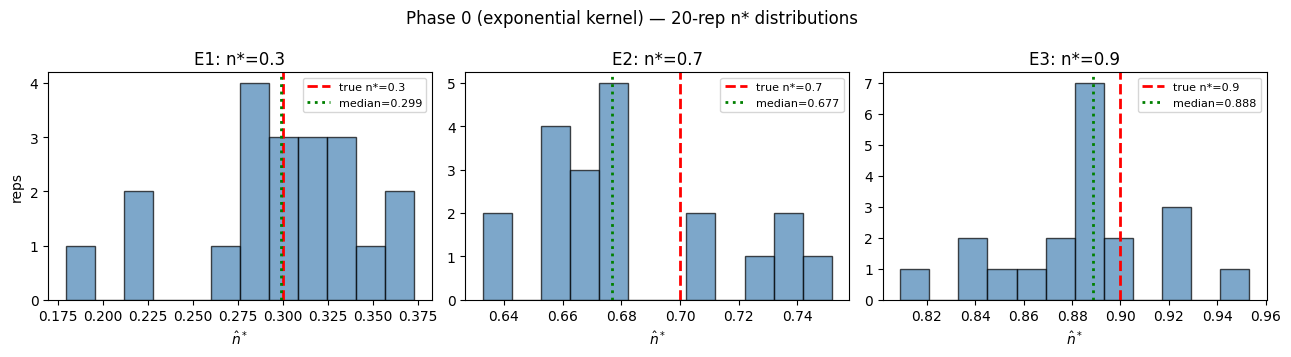

In [26]:
phase0 = {tag: json.load((RESULTS_DIR / f"phase0_{tag}_results.json").open())
          for tag in ("E1", "E2", "E3")}

def _ok_rows(d):
    return [r for r in d["results"] if r.get("ok")]

def med_err(arr, true):
    return float(np.median([abs(x / true - 1) for x in arr]))

phase0_summary = {}
for tag, d in phase0.items():
    ok = _ok_rows(d)
    ns = [r["n_star_h"] for r in ok]
    mus = [r["mu_h"] for r in ok]
    alphas = [r["alpha_h"] for r in ok]
    deltas = [r["delta_h"] for r in ok]
    ks_ps = [r["ks_p"] for r in ok]
    true = d["true"]
    phase0_summary[tag] = {
        "tag": tag,
        "true": true,
        "n_ok": len(ok),
        "n_star_median": float(np.median(ns)),
        "n_star_std": float(np.std(ns)),
        "n_star_err": med_err(ns, true["n_star"]),
        "alpha_err": med_err(alphas, true["alpha"]),
        "delta_err": med_err(deltas, true["delta"]),
        "mu_err": med_err(mus, true["mu"]),
        "ks_pass_rate": sum(1 for p in ks_ps if p > 0.05) / len(ks_ps),
    }

print(f"{'tag':<4} {'n*true':>7} {'n*med':>8} {'n*err':>8} {'alphaErr':>10} {'deltaErr':>10} {'muErr':>8} {'KS':>6}")
print("-" * 70)
for tag, s in phase0_summary.items():
    print(
        f"{tag:<4} {s['true']['n_star']:>7.2f} {s['n_star_median']:>8.3f} "
        f"{s['n_star_err']*100:>7.2f}% {s['alpha_err']*100:>9.2f}% "
        f"{s['delta_err']*100:>9.2f}% {s['mu_err']*100:>7.2f}% "
        f"{s['ks_pass_rate']*100:>5.0f}%"
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, tag in zip(axes, ("E1", "E2", "E3")):
    d = phase0[tag]
    ns = [r["n_star_h"] for r in _ok_rows(d)]
    true = d["true"]["n_star"]
    ax.hist(ns, bins=12, alpha=0.7, color="steelblue", edgecolor="black")
    ax.axvline(true, color="red", ls="--", lw=2, label=f"true n*={true}")
    ax.axvline(np.median(ns), color="green", ls=":", lw=2, label=f"median={np.median(ns):.3f}")
    ax.set_title(f"{tag}: n*={true}"); ax.set_xlabel(r"$\hat{n}^*$"); ax.legend(fontsize=8)
axes[0].set_ylabel("reps")
plt.suptitle("Phase 0 (exponential kernel) — 20-rep n* distributions")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig05_phase0_distribution.png", dpi=120)
plt.show()

## §4.4 — Phase 1 (unmarked power-law) synthetic recovery

The same multi-start L-BFGS-B fitter applied to the unmarked power-law kernel. Same three branching-ratio regimes R1 / R2 / R3 with `n* = 0.3 / 0.7 / 0.9`, 20 reps each. The `(alpha, delta, eta)` ridge collapses individual identification and worsens toward criticality. Pre-computed snapshots are loaded from `phase1_R{1,2,3}_results.json`.

tag   n*true     n*med     n*max  alphaRatio   eta@lb     KS
----------------------------------------------------------------------
R1      0.30     0.281      0.38      702.73   0/20    100%
R2      0.70     0.510     74.31       34.03   3/20    100%
R3      0.90    96.578   9503.63        0.10   8/20    100%


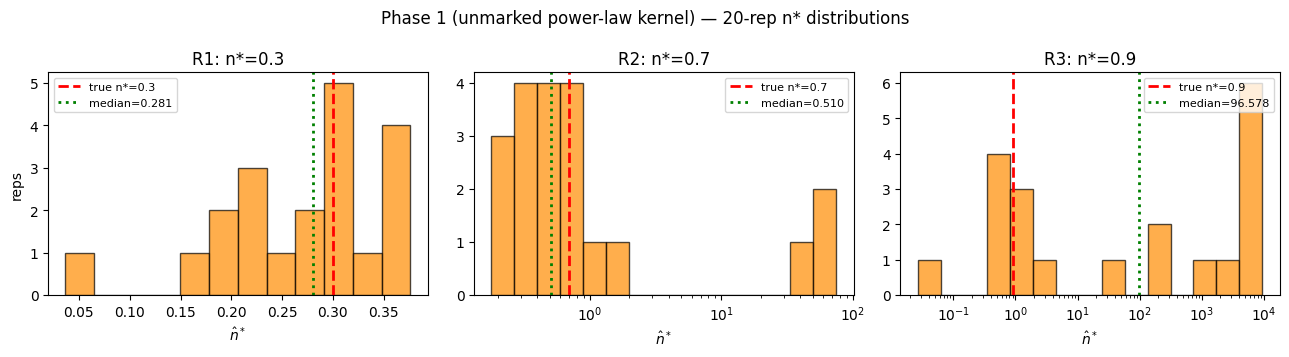

In [27]:
phase1 = {tag: json.load((RESULTS_DIR / f"phase1_{tag}_results.json").open())
          for tag in ("R1", "R2", "R3")}

phase1_summary = {}
for tag, d in phase1.items():
    ok = _ok_rows(d)
    ns = [r["n_star_h"] for r in ok]
    alphas = [r["alpha_h"] for r in ok]
    deltas = [r["delta_h"] for r in ok]
    etas = [r["eta_h"] for r in ok]
    mus = [r["mu_h"] for r in ok]
    ks_ps = [r["ks_p"] for r in ok]
    true = d["true"]
    phase1_summary[tag] = {
        "tag": tag,
        "true": true,
        "n_ok": len(ok),
        "n_star_median": float(np.median(ns)),
        "n_star_max": float(max(ns)),
        "n_star_std": float(np.std(ns)),
        "alpha_ratio_median": float(np.median([a / true["alpha"] for a in alphas])),
        "eta_at_lb_count": sum(1 for r in ok if r.get("eta_at_lb")),
        "alpha_at_ub_count": sum(1 for r in ok if r.get("alpha_at_ub")),
        "ks_pass_rate": sum(1 for p in ks_ps if p > 0.05) / len(ks_ps),
    }

print(f"{'tag':<4} {'n*true':>7} {'n*med':>9} {'n*max':>9} {'alphaRatio':>11} {'eta@lb':>8} {'KS':>6}")
print("-" * 70)
for tag, s in phase1_summary.items():
    print(
        f"{tag:<4} {s['true']['n_star']:>7.2f} {s['n_star_median']:>9.3f} "
        f"{s['n_star_max']:>9.2f} {s['alpha_ratio_median']:>11.2f} "
        f"{s['eta_at_lb_count']:>3d}/20  {s['ks_pass_rate']*100:>5.0f}%"
    )

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, tag in zip(axes, ("R1", "R2", "R3")):
    d = phase1[tag]
    ns = np.array([r["n_star_h"] for r in _ok_rows(d)])
    true = d["true"]["n_star"]
    span_ratio = ns.max() / max(ns.min(), 1e-6)
    if span_ratio > 50:
        bins = np.logspace(np.log10(max(ns.min(), 1e-3)), np.log10(ns.max() + 1), 16)
        ax.set_xscale("log")
    else:
        bins = 12
    ax.hist(ns, bins=bins, alpha=0.7, color="darkorange", edgecolor="black")
    ax.axvline(true, color="red", ls="--", lw=2, label=f"true n*={true}")
    ax.axvline(np.median(ns), color="green", ls=":", lw=2, label=f"median={np.median(ns):.3f}")
    ax.set_title(f"{tag}: n*={true}"); ax.set_xlabel(r"$\hat{n}^*$"); ax.legend(fontsize=8)
axes[0].set_ylabel("reps")
plt.suptitle("Phase 1 (unmarked power-law kernel) — 20-rep n* distributions")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig06_phase1_distribution.png", dpi=120)
plt.show()

## §4.5 — Hardiman–Bouchaud cross-check on Spock

An independent estimator that does not pass through the marked-power-law likelihood. The H-B sub-window estimate places `n*` below 1 across every observed window width. The values rise monotonically with `Δt` because the cascade is non-stationary, so any single `Δt` is at best a lower bound.

Spock cascade: N=219, T_full=241072 s
 dt(s)  n_wins     E[N]    Var[N]     Fano     n_HB
--------------------------------------------------------
    60    4017    0.054     0.226    4.158   0.5096
   120    2008    0.109     0.818    7.537   0.6358
   300     803    0.271     4.330   15.950   0.7496
   600     401    0.544    14.474   26.624   0.8062
  1800     133    1.639   106.384   64.904   0.8759


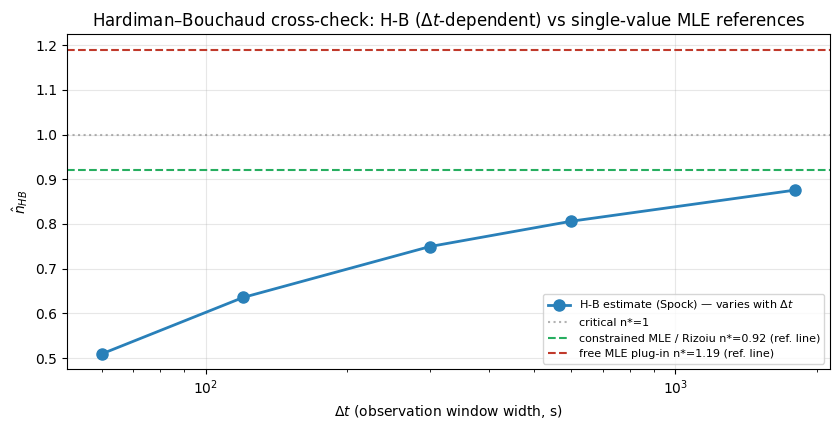

In [34]:
hb_spock = json.load((RESULTS_DIR / "hb_spock.json").open())
sweep = hb_spock["sweep"]
print(f"Spock cascade: N={hb_spock['N']}, T_full={hb_spock['T_full_s']:.0f} s")
print(f"{'dt(s)':>6} {'n_wins':>7} {'E[N]':>8} {'Var[N]':>9} {'Fano':>8} {'n_HB':>8}")
print("-" * 56)
for r in sweep:
    print(f"{r['delta_t']:>6.0f} {r['n_windows']:>7d} {r['E_N']:>8.3f} "
          f"{r['Var_N']:>9.3f} {r['Fano']:>8.3f} {r['n_hb']:>8.4f}")

n_hbs = [r["n_hb"] for r in sweep]
dts   = [r["delta_t"] for r in sweep]
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(dts, n_hbs, "o-", color="#2980b9", lw=2, ms=8,
        label=r"H-B estimate (Spock) — varies with $\Delta t$", zorder=3)
ax.axhline(1.0, color="gray", ls=":", alpha=0.6, label="critical n*=1")
ax.axhline(RIZOIU_N_REPORTED, color="#27ae60", ls="--",
           label=f"constrained MLE / Rizoiu n*={RIZOIU_N_REPORTED} (ref. line)")
ax.axhline(hb_spock["our_mle_n_star_plugin"], color="#c0392b", ls="--",
           label=f"free MLE plug-in n*={hb_spock['our_mle_n_star_plugin']:.2f} (ref. line)")
ax.set_xscale("log")
ax.set_xlabel(r"$\Delta t$ (observation window width, s)"); ax.set_ylabel(r"$\hat n_{HB}$")
ax.set_title(r"Hardiman–Bouchaud cross-check: H-B ($\Delta t$-dependent) vs single-value MLE references")
ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "fig07_hb_spock.png", dpi=120)
plt.show()

## §4.6 — Phase 2 (marked power-law) synthetic recovery

Same fitter as the real-data fit (§4.1), applied to synthetic marked-power-law data at three branching-ratio regimes `n* = 0.3 / 0.7 / 0.9` with true `β = 1.3`. Mark distribution `log10(m) ~ N(2.5, 1.0)`. Marked likelihood is `O(N^2)`, so this section is the slowest part of the notebook (~10 minutes). With `FORCE_RECOMPUTE = False` (default) the frozen snapshot at `phase2_marked.json` is loaded instead.

In [29]:
PHASE2_BOUNDS = [(1e-3, 5.0), (1e-6, 1e4), (0.1, 3.0), (0.1, 2000.0), (0.1, 5.0)]
PHASE2_SETTINGS = [
    dict(tag="P1", n_star=0.3, mu=0.4, beta=1.3, c=50.0, theta=1.3, T=600.0, seed=424242),
    dict(tag="P2", n_star=0.7, mu=0.3, beta=1.3, c=50.0, theta=1.3, T=500.0, seed=70707),
    dict(tag="P3", n_star=0.9, mu=0.2, beta=1.3, c=50.0, theta=1.3, T=450.0, seed=909090),
]

def _kappa_for(n_star, beta, c, theta):
    return n_star * theta * (c ** theta) / kernels.lognormal_E_m_beta(beta)

def _run_phase2():
    out = {}
    for s in PHASE2_SETTINGS:
        kap_true = _kappa_for(s["n_star"], s["beta"], s["c"], s["theta"])
        rng_loc = np.random.default_rng(s["seed"])
        rows = []
        t0 = time.time()
        for rep in range(10):
            tt, mm = simulate.simulate_marked_powerlaw(
                s["mu"], kap_true, s["beta"], s["c"], s["theta"], s["T"], rng_loc
            )
            tt, mm, T_eff = simulate.apply_burnin_marked(tt, mm, s["T"], 0.1)
            if len(tt) < 20:
                continue
            r = mle.fit_multi_start(
                likelihood.nll_marked_powerlaw, (tt, mm, T_eff),
                mle.sample_init_marked_free_beta, PHASE2_BOUNDS,
                n_inits=10, rng=rng_loc,
            )
            if r.best is None:
                continue
            mu_h, ka_h, be_h, c_h, th_h = r.best.params
            n_h = kernels.branching_factor_marked(
                ka_h, be_h, c_h, th_h, kernels.lognormal_E_m_beta(be_h)
            )
            rows.append(dict(rep=rep, N=int(len(tt)), n=float(n_h), beta=float(be_h)))
        ns = [x["n"] for x in rows]; bs = [x["beta"] for x in rows]
        out[s["tag"]] = dict(
            true_n=s["n_star"], true_beta=s["beta"], n_reps=len(rows),
            n_median=float(np.median(ns)) if ns else float("nan"),
            n_min=float(min(ns)) if ns else float("nan"),
            n_max=float(max(ns)) if ns else float("nan"),
            beta_median=float(np.median(bs)) if bs else float("nan"),
            rows=rows,
        )
        print(f"  {s['tag']} n*med={out[s['tag']]['n_median']:.3g} "
              f"beta_med={out[s['tag']]['beta_median']:.2f} ({time.time()-t0:.0f} s)")
    return out

PHASE2_PATH = RESULTS_DIR / "phase2_marked.json"
if FORCE_RECOMPUTE or not PHASE2_PATH.exists():
    print("recomputing Phase 2 marked-power-law recovery (~10 min)...")
    phase2 = _run_phase2()
    with PHASE2_PATH.open("w") as f:
        json.dump(phase2, f, indent=1)
else:
    phase2 = json.load(PHASE2_PATH.open())
    print(f"loaded {PHASE2_PATH.name}")

loaded phase2_marked.json


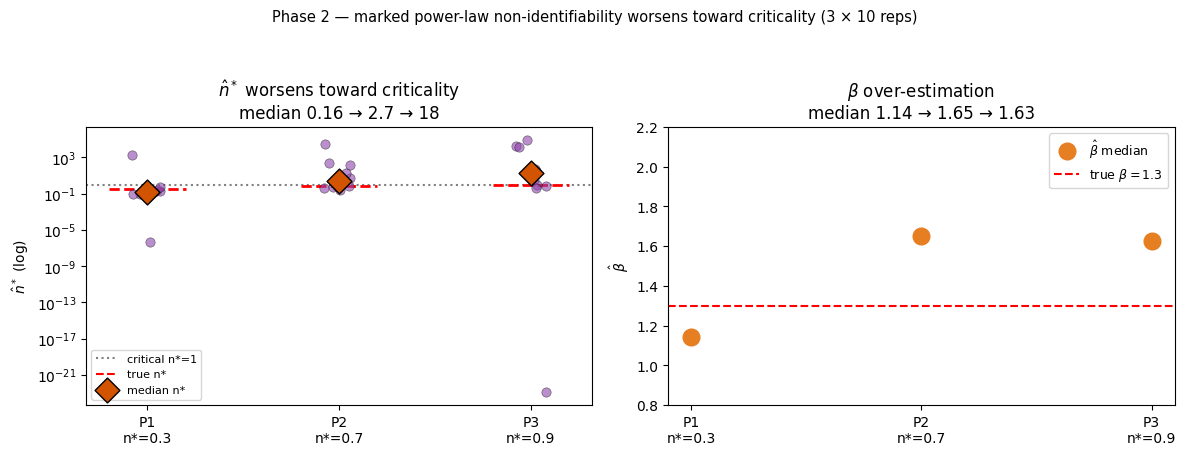

In [37]:
P = [phase2["P1"], phase2["P2"], phase2["P3"]]
tags = ["P1\nn*=0.3", "P2\nn*=0.7", "P3\nn*=0.9"]
true_n = [0.3, 0.7, 0.9]
rng_jit = np.random.default_rng(0)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
for i, p in enumerate(P):
    ns = [r["n"] for r in p["rows"] if r["n"] > 0]
    x = np.full(len(ns), i) + rng_jit.uniform(-0.08, 0.08, len(ns))
    ax1.scatter(x, ns, s=45, alpha=0.6, color="#8e44ad", edgecolor="k", linewidth=0.4, zorder=3)
    ax1.scatter([i], [p["n_median"]], s=160, marker="D", color="#d35400", edgecolor="k", zorder=4)
ax1.axhline(1.0, ls=":", color="gray", label="critical n*=1")
for i, t in enumerate(true_n):
    ax1.plot([i-0.2, i+0.2], [t, t], ls="--", color="red", lw=2, zorder=2)
ax1.plot([], [], ls="--", color="red", label="true n*")
ax1.scatter([], [], s=160, marker="D", color="#d35400", edgecolor="k", label="median n*")
ax1.set_yscale("log"); ax1.set_xticks([0,1,2]); ax1.set_xticklabels(tags); ax1.set_ylabel(r"$\hat n^*$ (log)")
ax1.set_title(f"$\\hat n^*$ worsens toward criticality\nmedian {P[0]['n_median']:.2g} → {P[1]['n_median']:.2g} → {P[2]['n_median']:.2g}")
ax1.legend(fontsize=8, loc="lower left")
bmed = [p["beta_median"] for p in P]
ax2.plot([0,1,2], bmed, "o", ms=12, color="#e67e22", zorder=3, label=r"$\hat\beta$ median")
ax2.axhline(1.3, ls="--", color="red", label=r"true $\beta=1.3$")
ax2.set_xticks([0,1,2]); ax2.set_xticklabels(tags); ax2.set_ylabel(r"$\hat\beta$")
ax2.set_ylim(0.8, 2.2)
ax2.set_title(f"$\\beta$ over-estimation\nmedian {bmed[0]:.2f} → {bmed[1]:.2f} → {bmed[2]:.2f}")
ax2.legend(fontsize=9)
fig.suptitle("Phase 2 — marked power-law non-identifiability worsens toward criticality (3 × 10 reps)", fontsize=10.5)
fig.tight_layout(rect=[0,0,1,0.93])
plt.savefig(RESULTS_DIR / "fig08_phase2_marked.png", dpi=130)
plt.show()

## §4.7 — ACTIVE 80-cascade faithful-constraint check

Beyond the Spock single case, this section samples 80 cascades from the ACTIVE dataset (Rizoiu group) stratified by cascade size and fits each one with the Mishra et al. (2016) closed-form `n* < 1` constraint via SLSQP, plus the Hill estimator for the per-cascade mark Pareto exponent. The fit produces `active80_faithful.json` and `diag2_alpha.json`. As with §4.6, with `FORCE_RECOMPUTE = False` the frozen JSON is loaded instead.

In [31]:
ACTIVE_PATH       = RESULTS_DIR / "active80_faithful.json"
DIAG2_ALPHA_PATH  = RESULTS_DIR / "diag2_alpha.json"

if FORCE_RECOMPUTE or not ACTIVE_PATH.exists() or not DIAG2_ALPHA_PATH.exists():
    print("running ACTIVE faithful-constraint fits (~5 min)...")
    fits = faithful_constraint.fit_active(ACTIVE_CSV, n_cascades=80, T_obs=T_OBS,
                                          seed=7, alpha=ALPHA_ASSUMED)
    active = [
        {"ci": r.cascade_index, "N": r.N, "n": r.n_hat, "beta": r.beta, "alpha_emp": r.alpha_emp}
        for r in fits
    ]
    with ACTIVE_PATH.open("w") as f:
        json.dump(active, f, indent=1)
    diag2_alpha = [{"ci": r.cascade_index, "alpha_emp": r.alpha_emp} for r in fits]
    with DIAG2_ALPHA_PATH.open("w") as f:
        json.dump(diag2_alpha, f, indent=1)
    print(f"  {len(active)} cascades fit")
else:
    active = json.load(ACTIVE_PATH.open())
    print(f"loaded {ACTIVE_PATH.name} ({len(active)} cascades)")
    if not DIAG2_ALPHA_PATH.exists():
        diag2_alpha = [{"ci": r["ci"], "alpha_emp": r["alpha_emp"]} for r in active]
        with DIAG2_ALPHA_PATH.open("w") as f:
            json.dump(diag2_alpha, f, indent=1)
        print(f"derived {DIAG2_ALPHA_PATH.name} from {ACTIVE_PATH.name}")

loaded active80_faithful.json (80 cascades)


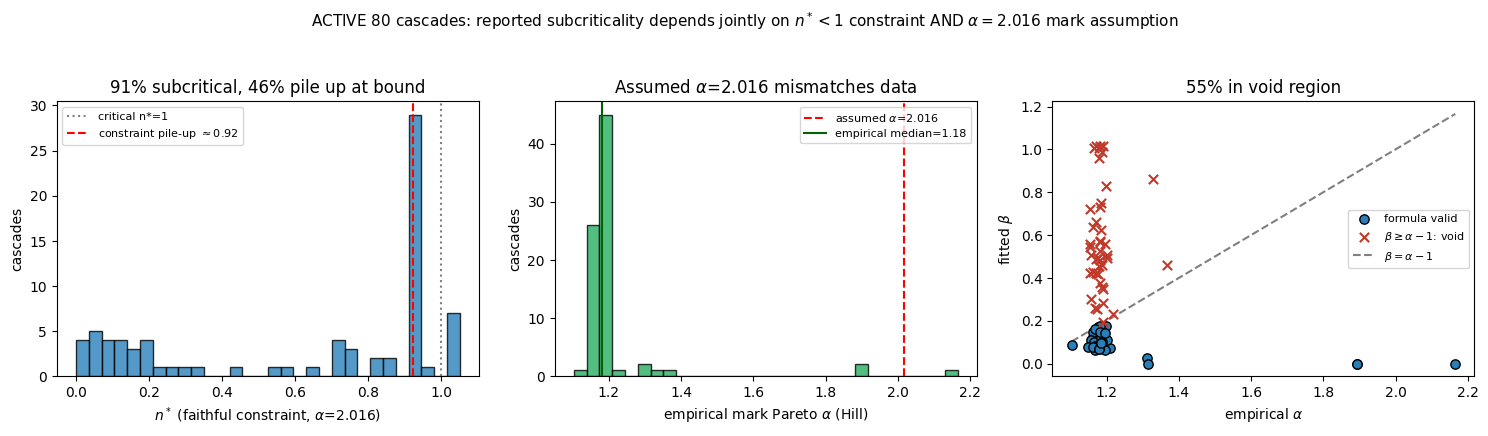

In [38]:
n_hat = np.array([r["n"] for r in active])
al    = np.array([r["alpha_emp"] for r in active])
beta  = np.array([r["beta"] for r in active])
exc   = beta >= (al - 1)  # closed-form invalid region

subcritical_rate = np.mean(n_hat < 1.01)
boundary_rate    = np.mean(n_hat > 0.9)
void_rate        = np.mean(exc)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4.4))
ax1.hist(np.clip(n_hat, 0, 1.05), bins=30, color="#2980b9", edgecolor="k", alpha=0.8)
ax1.axvline(1.0, ls=":", color="gray", label="critical n*=1")
ax1.axvline(0.9223, ls="--", color="red", label=r"constraint pile-up $\approx$0.92")
ax1.set_xlabel(r"$n^*$ (faithful constraint, $\alpha$=2.016)"); ax1.set_ylabel("cascades")
ax1.set_title(f"{subcritical_rate*100:.0f}% subcritical, {boundary_rate*100:.0f}% pile up at bound")
ax1.legend(fontsize=8)

ax2.hist(al, bins=30, color="#27ae60", edgecolor="k", alpha=0.8)
ax2.axvline(2.016, ls="--", color="red", label=r"assumed $\alpha$=2.016")
ax2.axvline(np.median(al), ls="-", color="darkgreen", label=f"empirical median={np.median(al):.2f}")
ax2.set_xlabel(r"empirical mark Pareto $\alpha$ (Hill)"); ax2.set_ylabel("cascades")
ax2.set_title(r"Assumed $\alpha$=2.016 mismatches data"); ax2.legend(fontsize=8, loc="upper right")

ax3.scatter(al[~exc], beta[~exc], s=45, color="#2980b9", edgecolor="k", label="formula valid", zorder=3)
ax3.scatter(al[exc], beta[exc], s=45, color="#c0392b", marker="x", label=r"$\beta\geq\alpha-1$: void", zorder=3)
xs = np.linspace(np.nanmin(al), np.nanmax(al), 100)
ax3.plot(xs, xs - 1, ls="--", color="gray", label=r"$\beta=\alpha-1$")
ax3.set_xlabel(r"empirical $\alpha$"); ax3.set_ylabel(r"fitted $\beta$")
ax3.set_title(f"{void_rate*100:.0f}% in void region"); ax3.legend(fontsize=8)

fig.suptitle(r"ACTIVE 80 cascades: reported subcriticality depends jointly on $n^*<1$ constraint AND $\alpha=2.016$ mark assumption", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(RESULTS_DIR / "fig09_active_constraint.png", dpi=130)
plt.show()

## Final summary

Aggregated verdict combining the Spock free / constrained fits, Phase 0 / 1 / 2, the Hardiman–Bouchaud sweep, and the ACTIVE 80-cascade check. Written to `final_summary.json`.

In [33]:
final_summary = {
    "dataset": "Spock retweet cascade (Rizoiu et al. 2017) + ACTIVE (Mishra et al. 2016)",
    "frozen_on": "2026-06-10",
    "spock": {
        "N_total": int(N_total),
        "N_obs": int(N_obs),
        "free_mle": {
            "params": fit_best.params,
            "nll": float(fit_best.nll),
            "n_star_plugin_unmarked": float(n_star_plugin_unmarked),
            "n_star_plugin_marked":   float(n_star_plugin_marked),
        },
        "constrained_mle": {
            "params": [float(K_c), float(beta_c), float(c_c), float(theta_c)],
            "n_star_closed_form": float(n_star_constrained),
            "alpha_assumed": ALPHA_ASSUMED,
        },
        "rizoiu_n_reported": RIZOIU_N_REPORTED,
    },
    "phase0_summary": phase0_summary,
    "phase1_summary": phase1_summary,
    "phase2_summary": {
        tag: {k: v for k, v in phase2[tag].items() if k != "rows"}
        for tag in ("P1", "P2", "P3")
    },
    "hb_spock": {
        "sweep": [
            {"delta_t": r["delta_t"], "n_hb": r["n_hb"], "Fano": r["Fano"]}
            for r in sweep
        ],
        "all_below_one": bool(all(r["n_hb"] < 1.0 for r in sweep)),
        "range": [float(min(n_hbs)), float(max(n_hbs))],
    },
    "active80": {
        "n_cascades": int(len(active)),
        "subcritical_rate": float(subcritical_rate),
        "boundary_pileup_rate": float(boundary_rate),
        "void_rate_beta_ge_alpha_minus_1": float(void_rate),
        "alpha_emp_median": float(np.median(al)),
        "alpha_assumed": ALPHA_ASSUMED,
    },
}
with (RESULTS_DIR / "final_summary.json").open("w") as f:
    json.dump(final_summary, f, indent=2, default=float)
print(f"saved: {RESULTS_DIR / 'final_summary.json'}")

saved: ../results/final_summary.json
